# Part 2b: Custom Loss, Activation, Initializer, Regularizer, and Constraint

This notebook covers building custom components for deep learning models.

## Topics Covered:
1. Custom Loss Functions (Huber, Focal Loss)
2. Custom Activation Functions (Swish, Mish)
3. Custom Weight Initializers
4. Custom Regularizers
5. Custom Weight Constraints

**Author:** Advanced Deep Learning Course Assignment

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

---
# Part A: Custom Components in TensorFlow/Keras

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(f"TensorFlow version: {tf.__version__}")
tf.random.set_seed(42)

TensorFlow version: 2.19.0


In [3]:
# Load data
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0
X_train = X_train[:10000]
y_train = y_train[:10000]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## 1. Custom Loss Functions

In [4]:
# 1.1 Huber Loss (smooth L1)
class HuberLoss(keras.losses.Loss):
    """
    Huber Loss - less sensitive to outliers than MSE.

    For small errors (< delta): L2 loss (quadratic)
    For large errors (>= delta): L1 loss (linear)
    """
    def __init__(self, delta=1.0, **kwargs):
        super().__init__(**kwargs)
        self.delta = delta

    def call(self, y_true, y_pred):
        error = y_true - y_pred
        abs_error = tf.abs(error)

        quadratic = tf.minimum(abs_error, self.delta)
        linear = abs_error - quadratic

        return 0.5 * tf.square(quadratic) + self.delta * linear

    def get_config(self):
        config = super().get_config()
        config.update({'delta': self.delta})
        return config

# Test Huber Loss
huber = HuberLoss(delta=1.0)
y_true = tf.constant([[0.0], [1.0], [2.0]])
y_pred = tf.constant([[0.5], [1.5], [5.0]])
print(f"Huber Loss: {huber(y_true, y_pred).numpy()}")

Huber Loss: 0.9166666865348816


In [5]:
# 1.2 Focal Loss (for imbalanced classification)
class FocalLoss(keras.losses.Loss):
    """
    Focal Loss - down-weights well-classified examples.

    Useful for highly imbalanced datasets.
    FL = -alpha * (1 - p)^gamma * log(p)
    """
    def __init__(self, gamma=2.0, alpha=0.25, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        # Clip predictions to prevent log(0)
        y_pred = tf.clip_by_value(y_pred, keras.backend.epsilon(), 1 - keras.backend.epsilon())

        # Compute focal loss
        cross_entropy = -y_true * tf.math.log(y_pred)
        focal_weight = self.alpha * tf.pow(1 - y_pred, self.gamma)
        focal_loss = focal_weight * cross_entropy

        return tf.reduce_sum(focal_loss, axis=-1)

    def get_config(self):
        config = super().get_config()
        config.update({'gamma': self.gamma, 'alpha': self.alpha})
        return config

# Test Focal Loss
focal = FocalLoss(gamma=2.0)
y_true = tf.constant([[1, 0, 0], [0, 1, 0]], dtype=tf.float32)
y_pred = tf.constant([[0.9, 0.05, 0.05], [0.1, 0.8, 0.1]], dtype=tf.float32)
print(f"Focal Loss: {focal(y_true, y_pred).numpy()}")

Focal Loss: 0.0012474183458834887


In [6]:
# 1.3 Contrastive Loss (for siamese networks)
class ContrastiveLoss(keras.losses.Loss):
    """
    Contrastive Loss for similarity learning.

    L = (1-Y) * 0.5 * D^2 + Y * 0.5 * max(0, margin - D)^2
    """
    def __init__(self, margin=1.0, **kwargs):
        super().__init__(**kwargs)
        self.margin = margin

    def call(self, y_true, y_pred):
        # y_true: 1 if similar, 0 if dissimilar
        # y_pred: distance between embeddings
        square_pred = tf.square(y_pred)
        margin_square = tf.square(tf.maximum(self.margin - y_pred, 0))

        return y_true * square_pred + (1 - y_true) * margin_square

print("Contrastive Loss created.")

Contrastive Loss created.


## 2. Custom Activation Functions

In [7]:
# 2.1 Leaky ReLU (custom implementation)
def my_leaky_relu(x, alpha=0.01):
    """
    Leaky ReLU: allows small negative values.
    f(x) = x if x > 0, else alpha * x
    """
    return tf.maximum(alpha * x, x)

# 2.2 Swish/SiLU activation
def swish(x):
    """
    Swish: x * sigmoid(x)
    Self-gated activation function.
    """
    return x * tf.nn.sigmoid(x)

# 2.3 Mish activation
def mish(x):
    """
    Mish: x * tanh(softplus(x))
    Smooth, non-monotonic activation.
    """
    return x * tf.nn.tanh(tf.nn.softplus(x))

# 2.4 GELU activation
def gelu(x):
    """
    Gaussian Error Linear Unit.
    Used in BERT and GPT.
    """
    return 0.5 * x * (1 + tf.tanh(tf.sqrt(2 / np.pi) * (x + 0.044715 * tf.pow(x, 3))))

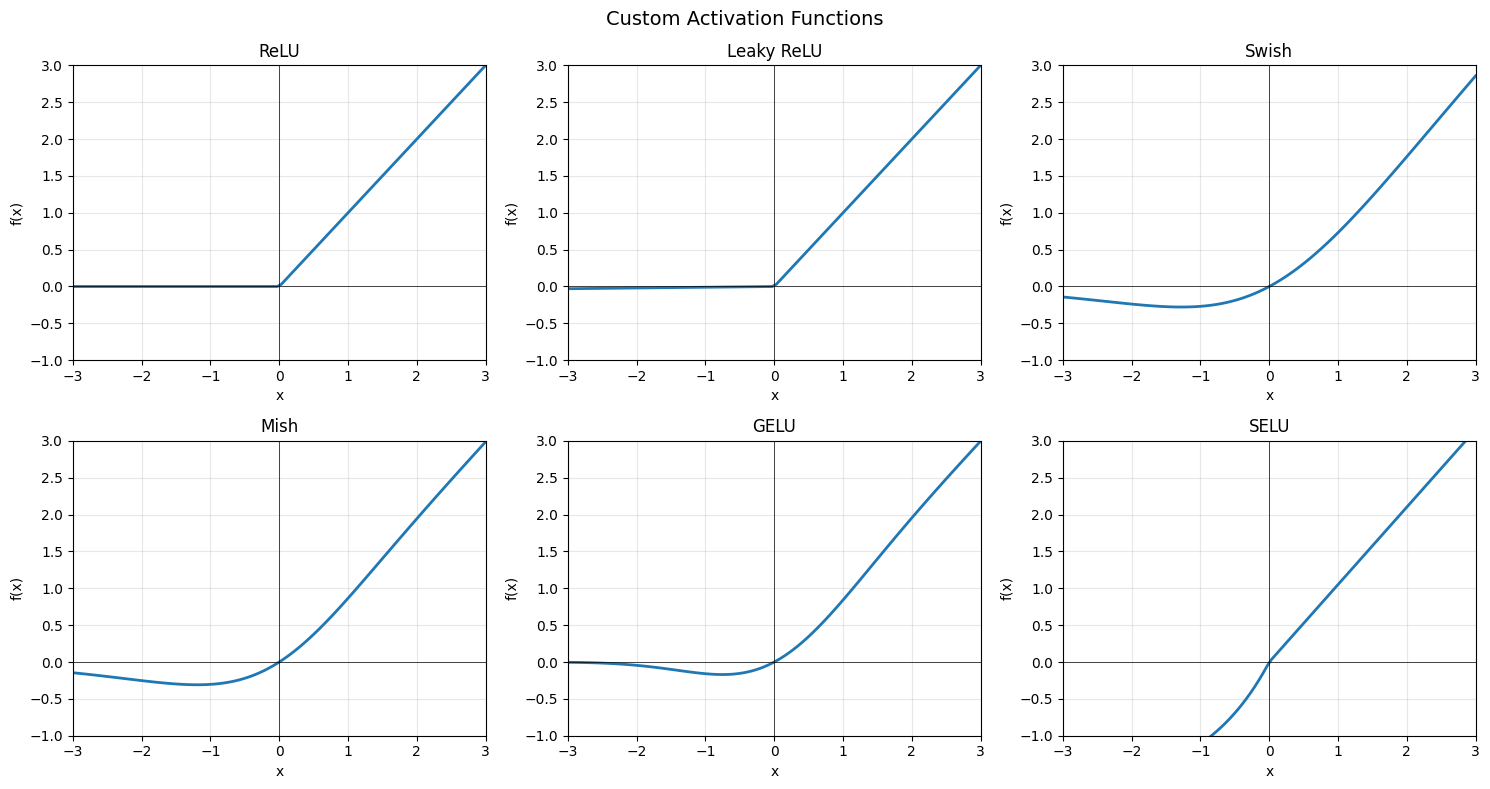

In [8]:
# Visualize custom activations
x = np.linspace(-3, 3, 100)
x_tensor = tf.constant(x, dtype=tf.float32)

activations = [
    ('ReLU', tf.nn.relu(x_tensor).numpy()),
    ('Leaky ReLU', my_leaky_relu(x_tensor).numpy()),
    ('Swish', swish(x_tensor).numpy()),
    ('Mish', mish(x_tensor).numpy()),
    ('GELU', gelu(x_tensor).numpy()),
    ('SELU', tf.nn.selu(x_tensor).numpy()),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Custom Activation Functions', fontsize=14)

for i, (name, y) in enumerate(activations):
    row = i // 3
    col = i % 3
    axes[row, col].plot(x, y, linewidth=2)
    axes[row, col].axhline(y=0, color='k', linewidth=0.5)
    axes[row, col].axvline(x=0, color='k', linewidth=0.5)
    axes[row, col].set_title(name)
    axes[row, col].set_xlabel('x')
    axes[row, col].set_ylabel('f(x)')
    axes[row, col].grid(True, alpha=0.3)
    axes[row, col].set_xlim(-3, 3)
    axes[row, col].set_ylim(-1, 3)

plt.tight_layout()
plt.show()

In [9]:
# Create activation as a Layer
class SwishActivation(layers.Layer):
    """
    Swish activation as a Keras layer.
    """
    def __init__(self, beta=1.0, trainable=False, **kwargs):
        super().__init__(**kwargs)
        self.beta_init = beta
        self.trainable_beta = trainable

    def build(self, input_shape):
        self.beta = self.add_weight(
            name='beta',
            shape=(),
            initializer=keras.initializers.Constant(self.beta_init),
            trainable=self.trainable_beta
        )
        super().build(input_shape)

    def call(self, inputs):
        return inputs * tf.nn.sigmoid(self.beta * inputs)

    def get_config(self):
        config = super().get_config()
        config.update({'beta': float(self.beta_init), 'trainable': self.trainable_beta})
        return config

## 3. Custom Weight Initializers

In [10]:
# 3.1 Custom Glorot Initializer
class MyGlorotInitializer(keras.initializers.Initializer):
    """
    Custom Glorot/Xavier initializer.

    Variance = 2 / (fan_in + fan_out)
    """
    def __init__(self, seed=None):
        self.seed = seed

    def __call__(self, shape, dtype=None):
        # Handle None dtype - default to float32
        if dtype is None:
            dtype = tf.float32

        fan_in = shape[0] if len(shape) > 0 else 1
        fan_out = shape[1] if len(shape) > 1 else shape[0]

        stddev = np.sqrt(2.0 / (fan_in + fan_out))
        return tf.random.normal(shape, mean=0, stddev=stddev, seed=self.seed, dtype=dtype)

    def get_config(self):
        return {'seed': self.seed}

# 3.2 Delta-Orthogonal Initializer
class DeltaOrthogonalInitializer(keras.initializers.Initializer):
    """
    Delta-orthogonal initialization for deep networks.

    For very deep networks, helps maintain gradient flow.
    """
    def __init__(self, gain=1.0, seed=None):
        self.gain = gain
        self.seed = seed

    def __call__(self, shape, dtype=None):
        # Handle None dtype - default to float32
        if dtype is None:
            dtype = tf.float32

        if len(shape) < 2:
            raise ValueError("Shape must be 2D or more")

        rows, cols = shape[0], np.prod(shape[1:])

        # Generate random matrix
        random_matrix = tf.random.normal([rows, cols], seed=self.seed, dtype=dtype)

        # Orthogonalize via QR decomposition
        if rows <= cols:
            q, _ = tf.linalg.qr(tf.transpose(random_matrix))
            q = tf.transpose(q)
        else:
            q, _ = tf.linalg.qr(random_matrix)

        q = self.gain * q[:rows, :]
        return tf.reshape(q, shape)

    def get_config(self):
        return {'gain': self.gain, 'seed': self.seed}

# Test initializers
glorot = MyGlorotInitializer(seed=42)
weights = glorot((128, 64))
print(f"Custom Glorot: mean={weights.numpy().mean():.4f}, std={weights.numpy().std():.4f}")

Custom Glorot: mean=-0.0006, std=0.1022


## 4. Custom Regularizers

In [11]:
# 4.1 Custom L1 Regularizer
class MyL1Regularizer(keras.regularizers.Regularizer):
    """
    Custom L1 regularizer with configurable strength.
    """
    def __init__(self, l1=0.01):
        self.l1 = l1

    def __call__(self, weights):
        return self.l1 * tf.reduce_sum(tf.abs(weights))

    def get_config(self):
        return {'l1': float(self.l1)}

# 4.2 Spectral Regularizer
class SpectralRegularizer(keras.regularizers.Regularizer):
    """
    Spectral regularization - penalizes largest singular value.

    Encourages Lipschitz continuity.
    """
    def __init__(self, factor=0.01):
        self.factor = factor

    def __call__(self, weights):
        if len(weights.shape) < 2:
            return 0.0

        # Compute largest singular value
        s = tf.linalg.svd(weights, compute_uv=False)
        spectral_norm = s[0]  # Largest singular value

        return self.factor * spectral_norm

    def get_config(self):
        return {'factor': float(self.factor)}

# Test regularizers
l1_reg = MyL1Regularizer(0.01)
test_weights = tf.constant([[1.0, -2.0], [3.0, -4.0]])
print(f"L1 penalty: {l1_reg(test_weights).numpy():.4f}")

L1 penalty: 0.1000


## 5. Custom Weight Constraints

In [12]:
# 5.1 Positive Weights Constraint
class PositiveWeights(keras.constraints.Constraint):
    """
    Constraint that clips weights to be non-negative.
    """
    def __call__(self, weights):
        return tf.maximum(weights, 0.0)

    def get_config(self):
        return {}

# 5.2 Unit Norm Constraint (per row)
class UnitNormConstraint(keras.constraints.Constraint):
    """
    Constraint that normalizes weights to unit norm.
    """
    def __init__(self, axis=0):
        self.axis = axis

    def __call__(self, weights):
        return weights / (tf.norm(weights, axis=self.axis, keepdims=True) + keras.backend.epsilon())

    def get_config(self):
        return {'axis': self.axis}

# 5.3 Max Norm Constraint
class MaxNormConstraint(keras.constraints.Constraint):
    """
    Constraint that clips weight norm to a maximum value.
    """
    def __init__(self, max_value=2.0, axis=0):
        self.max_value = max_value
        self.axis = axis

    def __call__(self, weights):
        norms = tf.norm(weights, axis=self.axis, keepdims=True)
        desired = tf.clip_by_value(norms, 0, self.max_value)
        return weights * (desired / (norms + keras.backend.epsilon()))

    def get_config(self):
        return {'max_value': self.max_value, 'axis': self.axis}

In [13]:
# Build a model using all custom components
def build_custom_model():
    model = keras.Sequential([
        layers.Flatten(input_shape=(28, 28)),

        layers.Dense(
            256,
            kernel_initializer=MyGlorotInitializer(seed=42),
            kernel_regularizer=MyL1Regularizer(0.001),
            kernel_constraint=MaxNormConstraint(max_value=3.0)
        ),
        SwishActivation(beta=1.0),
        layers.Dropout(0.3),

        layers.Dense(
            128,
            kernel_initializer=MyGlorotInitializer(seed=42),
            kernel_regularizer=MyL1Regularizer(0.001)
        ),
        layers.Lambda(lambda x: mish(x)),  # Using custom activation
        layers.Dropout(0.3),

        layers.Dense(10, activation='softmax')
    ])
    return model

# Create and compile model
custom_model = build_custom_model()
custom_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
custom_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ swish_activation                │ (None, 256)            │             1 │
│ (SwishActivation)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,147 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 1 (4.00 B)

In [14]:
# Train with custom components
print("Training with custom components...")
history = custom_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Evaluate
test_loss, test_acc = custom_model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")

Training with custom components...
Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6812 - loss: 4.9190 - val_accuracy: 0.7485 - val_loss: 2.5240
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7341 - loss: 1.9925 - val_accuracy: 0.7575 - val_loss: 1.5693
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7360 - loss: 1.4821 - val_accuracy: 0.7660 - val_loss: 1.3005
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7465 - loss: 1.2952 - val_accuracy: 0.7750 - val_loss: 1.1644
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7546 - loss: 1.1991 - val_accuracy: 0.7885 - val_loss: 1.0835
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7579 - loss: 1.1502 - val_accuracy: 0.7795 - val_loss: 1.0726
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7651 - loss: 1.0994 - val_accuracy: 0.7845 - val_loss: 1.0155
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.767

---
# Part B: Custom Components in PyTorch

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F

print(f"PyTorch version: {torch.__version__}")
torch.manual_seed(42)

PyTorch version: 2.10.0+cu128


In [16]:
# PyTorch Custom Loss Functions

class HuberLossPyTorch(nn.Module):
    """Huber Loss for PyTorch."""
    def __init__(self, delta=1.0):
        super().__init__()
        self.delta = delta

    def forward(self, y_pred, y_true):
        error = y_true - y_pred
        abs_error = torch.abs(error)

        quadratic = torch.clamp(abs_error, max=self.delta)
        linear = abs_error - quadratic

        return torch.mean(0.5 * quadratic ** 2 + self.delta * linear)


class FocalLossPyTorch(nn.Module):
    """Focal Loss for PyTorch."""
    def __init__(self, gamma=2.0, alpha=0.25):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

print("PyTorch custom losses created.")

PyTorch custom losses created.


In [17]:
# PyTorch Custom Activations

class Swish(nn.Module):
    """Swish activation for PyTorch."""
    def __init__(self, beta=1.0, trainable=False):
        super().__init__()
        if trainable:
            self.beta = nn.Parameter(torch.tensor(beta))
        else:
            self.beta = beta

    def forward(self, x):
        return x * torch.sigmoid(self.beta * x)


class Mish(nn.Module):
    """Mish activation for PyTorch."""
    def forward(self, x):
        return x * torch.tanh(F.softplus(x))


class GELU(nn.Module):
    """GELU activation for PyTorch."""
    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            np.sqrt(2 / np.pi) * (x + 0.044715 * torch.pow(x, 3))
        ))

print("PyTorch custom activations created.")

PyTorch custom activations created.


In [18]:
# PyTorch Custom Initializers

def custom_glorot_init(tensor):
    """Custom Glorot initialization."""
    fan_in = tensor.size(1) if tensor.dim() > 1 else tensor.size(0)
    fan_out = tensor.size(0)
    std = np.sqrt(2.0 / (fan_in + fan_out))
    with torch.no_grad():
        tensor.normal_(0, std)
    return tensor

def custom_orthogonal_init(tensor, gain=1.0):
    """Custom orthogonal initialization."""
    nn.init.orthogonal_(tensor, gain=gain)
    return tensor

print("PyTorch custom initializers created.")

PyTorch custom initializers created.


In [19]:
# PyTorch model with custom components

class CustomNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(784, 256)
        self.act1 = Swish(beta=1.0)
        self.drop1 = nn.Dropout(0.3)

        self.fc2 = nn.Linear(256, 128)
        self.act2 = Mish()
        self.drop2 = nn.Dropout(0.3)

        self.fc3 = nn.Linear(128, 10)

        # Apply custom initialization
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                custom_glorot_init(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = x.view(-1, 784)
        x = self.drop1(self.act1(self.fc1(x)))
        x = self.drop2(self.act2(self.fc2(x)))
        return self.fc3(x)

# Create and test
model_pt = CustomNet()
print(model_pt)

CustomNet(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (act1): Swish()
  (drop1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (act2): Mish()
  (drop2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


---
## Summary

### Custom Components Overview:

| Component | TensorFlow | PyTorch |
|-----------|------------|----------|
| **Loss** | Subclass `keras.losses.Loss` | Subclass `nn.Module` |
| **Activation** | Function or `layers.Layer` | Subclass `nn.Module` |
| **Initializer** | Subclass `keras.initializers.Initializer` | Function with `torch.no_grad()` |
| **Regularizer** | Subclass `keras.regularizers.Regularizer` | Add penalty to loss in training loop |
| **Constraint** | Subclass `keras.constraints.Constraint` | Apply in `forward()` or use hooks |

### Best Practices:
1. Always implement `get_config()` for Keras components (for serialization)
2. Use `@tf.function` for performance in TensorFlow
3. Test custom components on small inputs before training
4. Document expected input shapes and ranges